In [1]:
from pathlib import Path

import pyvista as pv
import pandas as pd
import meshio
import numpy as np
import matplotlib.pyplot as plt

from volume_reader import get_volume_at_time

In [2]:
filename = "../PolyFEM/Thigh-pad/six-channel/sim_outputs/sim_nine_poke_test_ignore_cavity_try7/sim.pvd"
reader = pv.get_reader(filename)

id_interior = 11
v_0 = get_volume_at_time(reader, 0, id_interior)
ps = []
vs = []

In [4]:
read_from_pvd = False
csv_path = "../PolyFEM/Thigh-pad/six-channel/sim_outputs/sim_nine_poke_test_ignore_cavity_try7/sim_pressures.csv"

if read_from_pvd:
    for t in reader.time_values:
        v_t = get_volume_at_time(reader, t, id_interior)
        p_t_ratio = v_0/v_t
        vs.append(v_t)
        ps.append(p_t_ratio)
    
    df_sim_result = pd.DataFrame({"times": reader.time_values, "volumes": vs, "pressures": ps})
    df_sim_result.to_csv(csv_path, index=False)
else:
    df_sim_result = pd.read_csv(csv_path)

[(0.5, 14), (13.5, 27), (26.5, 40), (39.5, 53), (52.5, 66), (65.5, 79), (78.5, 92), (91.5, 105), (104.5, 118)]


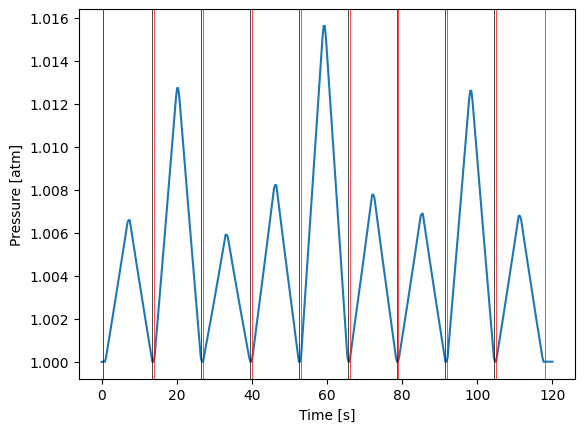

In [5]:
#pad_intervals = ((0, 14), (13.5, 27), (26.5 40), etc
poke_intervals = [(i*13+0.5, (i+1)*13+1) for i in range(9)]
print(poke_intervals)

fig = plt.figure()
plt.plot(df_sim_result["times"], df_sim_result["pressures"])
plt.xlabel("Time [s]")
plt.ylabel("Pressure [atm]")
for interval in poke_intervals:
    plt.axvline(x=interval[0], color="k", linewidth=0.5)
    plt.axvline(x=interval[1], color="r", linewidth=0.5)

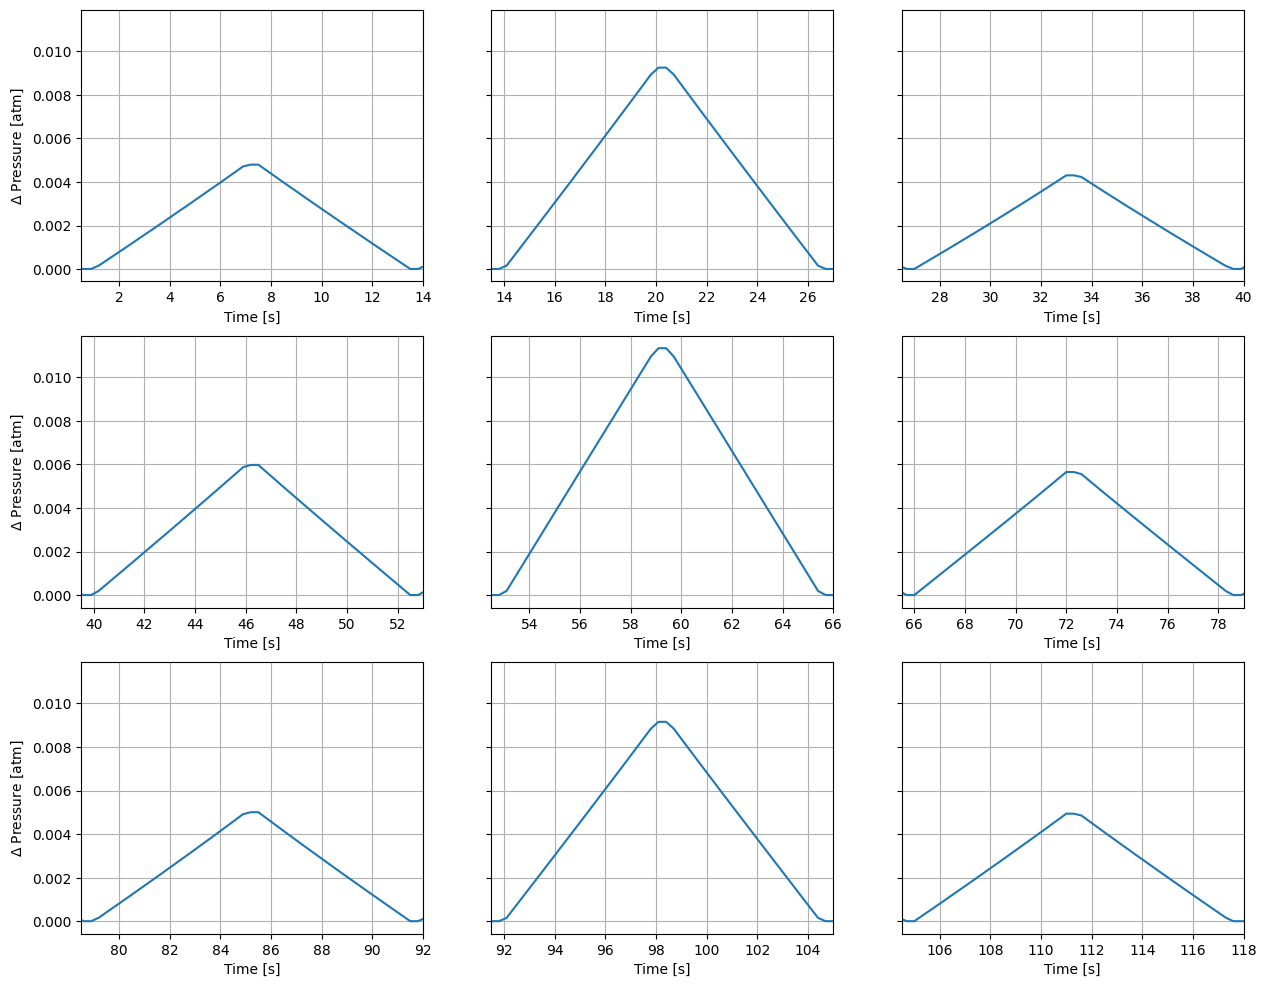

In [6]:
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(15, 12), sharey=True)

tube_diameter = 0.0254/16       # 1/16" in meters
tube_length = 576.22 / 1e3      # 576.22mm in meters
tube_vol = (np.pi * (tube_diameter/2)**2) * tube_length
v_initial = df_sim_result["volumes"][0] + tube_vol
ps_total = v_initial / (df_sim_result["volumes"] + tube_vol)

i_poke = 0
for i in range(3):
    for j in range(3):
        interval_i = poke_intervals[i_poke]
        axs[i, j].plot(df_sim_result["times"], ps_total-1)
        axs[i, j].set_xlim(interval_i)

        i_poke += 1
        axs[i,j].grid(True)
        axs[i,j].set_xlabel("Time [s]")
        if j == 0:
            axs[i,j].set_ylabel("$\\Delta$ Pressure [atm]")

**Figure to replicate**

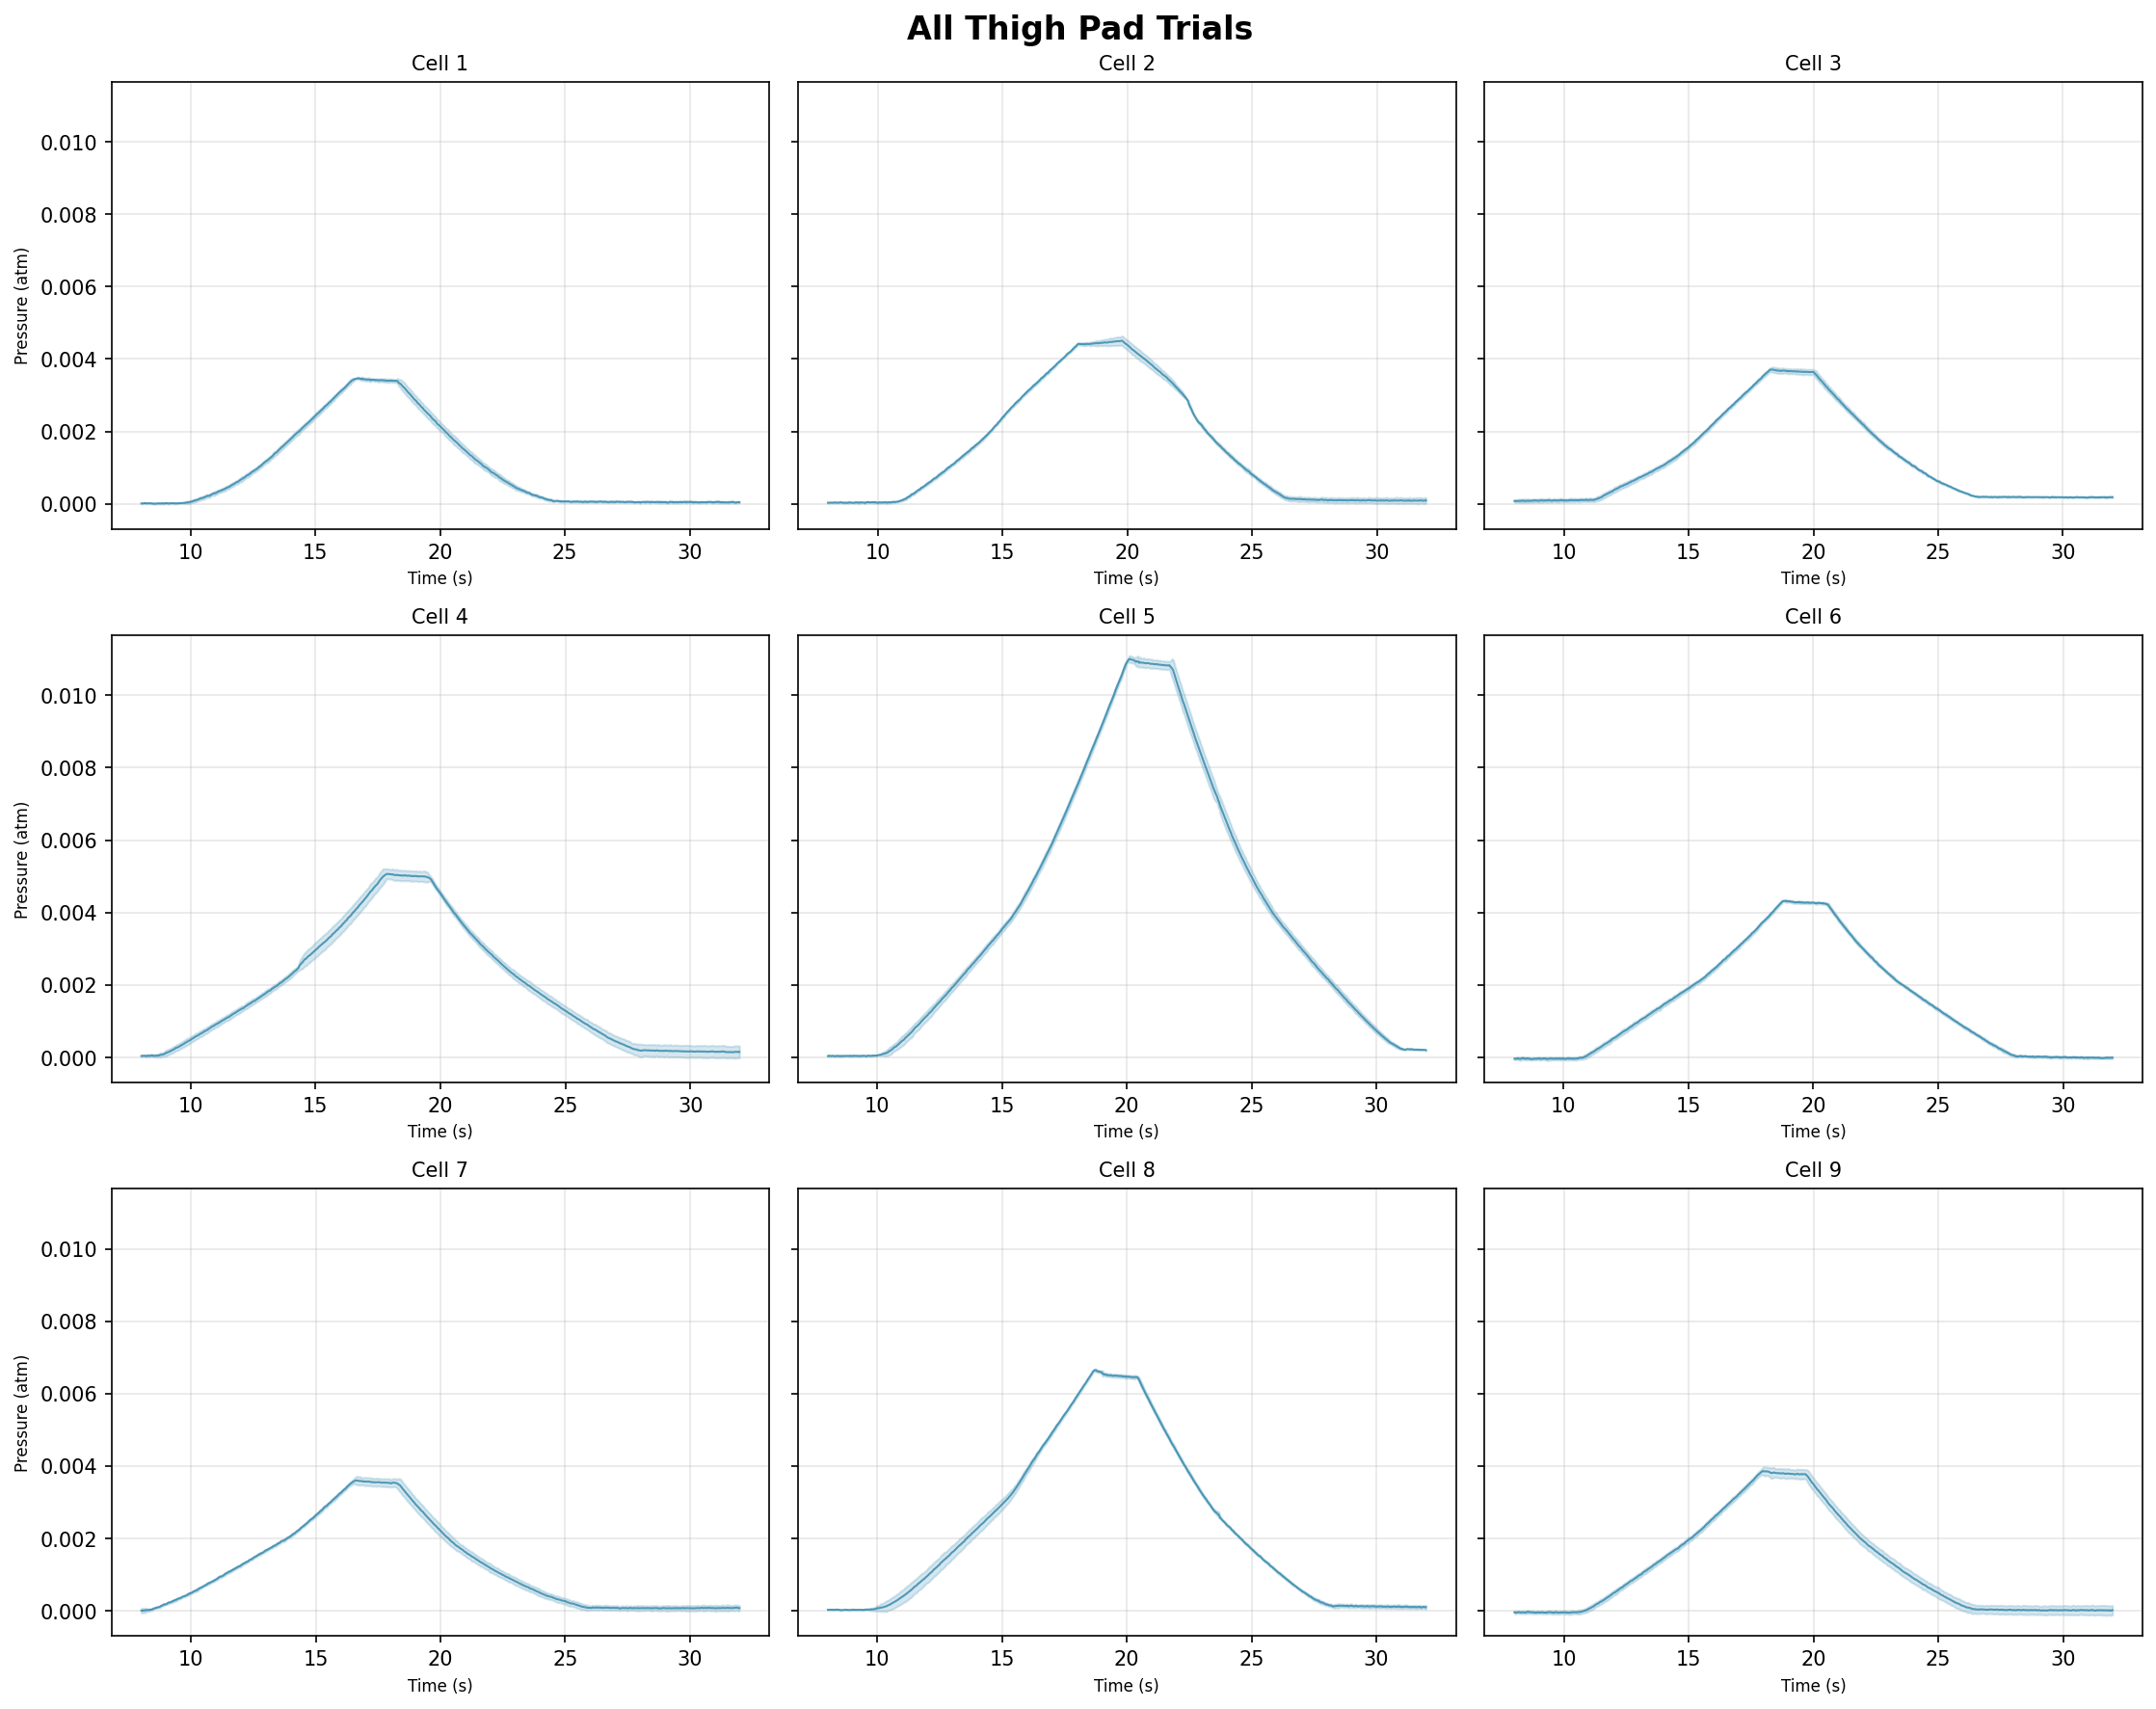

In [8]:
# TODO - how much dx was there in the real dataset?
# Define the path to your folder
folder_path = Path("../Data/Gilbert/Thigh_pad/pokes") # Use forward slashes for cross-platform compatibility

# Loop through all items in the directory
list_poke_dfs = [[None, None, None] for i in range(9)]

# Dict of lists
for file_path in folder_path.iterdir():
    # Check if the current item is a file
    if file_path.is_file():
        i_poke = int(file_path.stem[14])
        i_repeat = int(file_path.stem[16])
        list_poke_dfs[i_poke - 1][i_repeat - 1] = pd.read_csv(file_path)

Poke 1 test 1, Compression start at 86.822, Compression end at 84.580, dx is -2.242
Poke 1 test 2, Compression start at 86.740, Compression end at 84.581, dx is -2.159
Poke 1 test 3, Compression start at 86.736, Compression end at 84.522, dx is -2.215
Poke 2 test 1, Compression start at 86.495, Compression end at 84.061, dx is -2.434
Poke 2 test 2, Compression start at 86.454, Compression end at 84.063, dx is -2.391
Poke 2 test 3, Compression start at 86.440, Compression end at 84.062, dx is -2.379
Poke 3 test 1, Compression start at 86.329, Compression end at 84.022, dx is -2.308
Poke 3 test 2, Compression start at 86.295, Compression end at 84.021, dx is -2.274
Poke 3 test 3, Compression start at 86.286, Compression end at 83.981, dx is -2.305
Poke 4 test 1, Compression start at 87.188, Compression end at 84.162, dx is -3.025
Poke 4 test 2, Compression start at 87.110, Compression end at 84.141, dx is -2.968
Poke 4 test 3, Compression start at 87.056, Compression end at 84.121, dx is

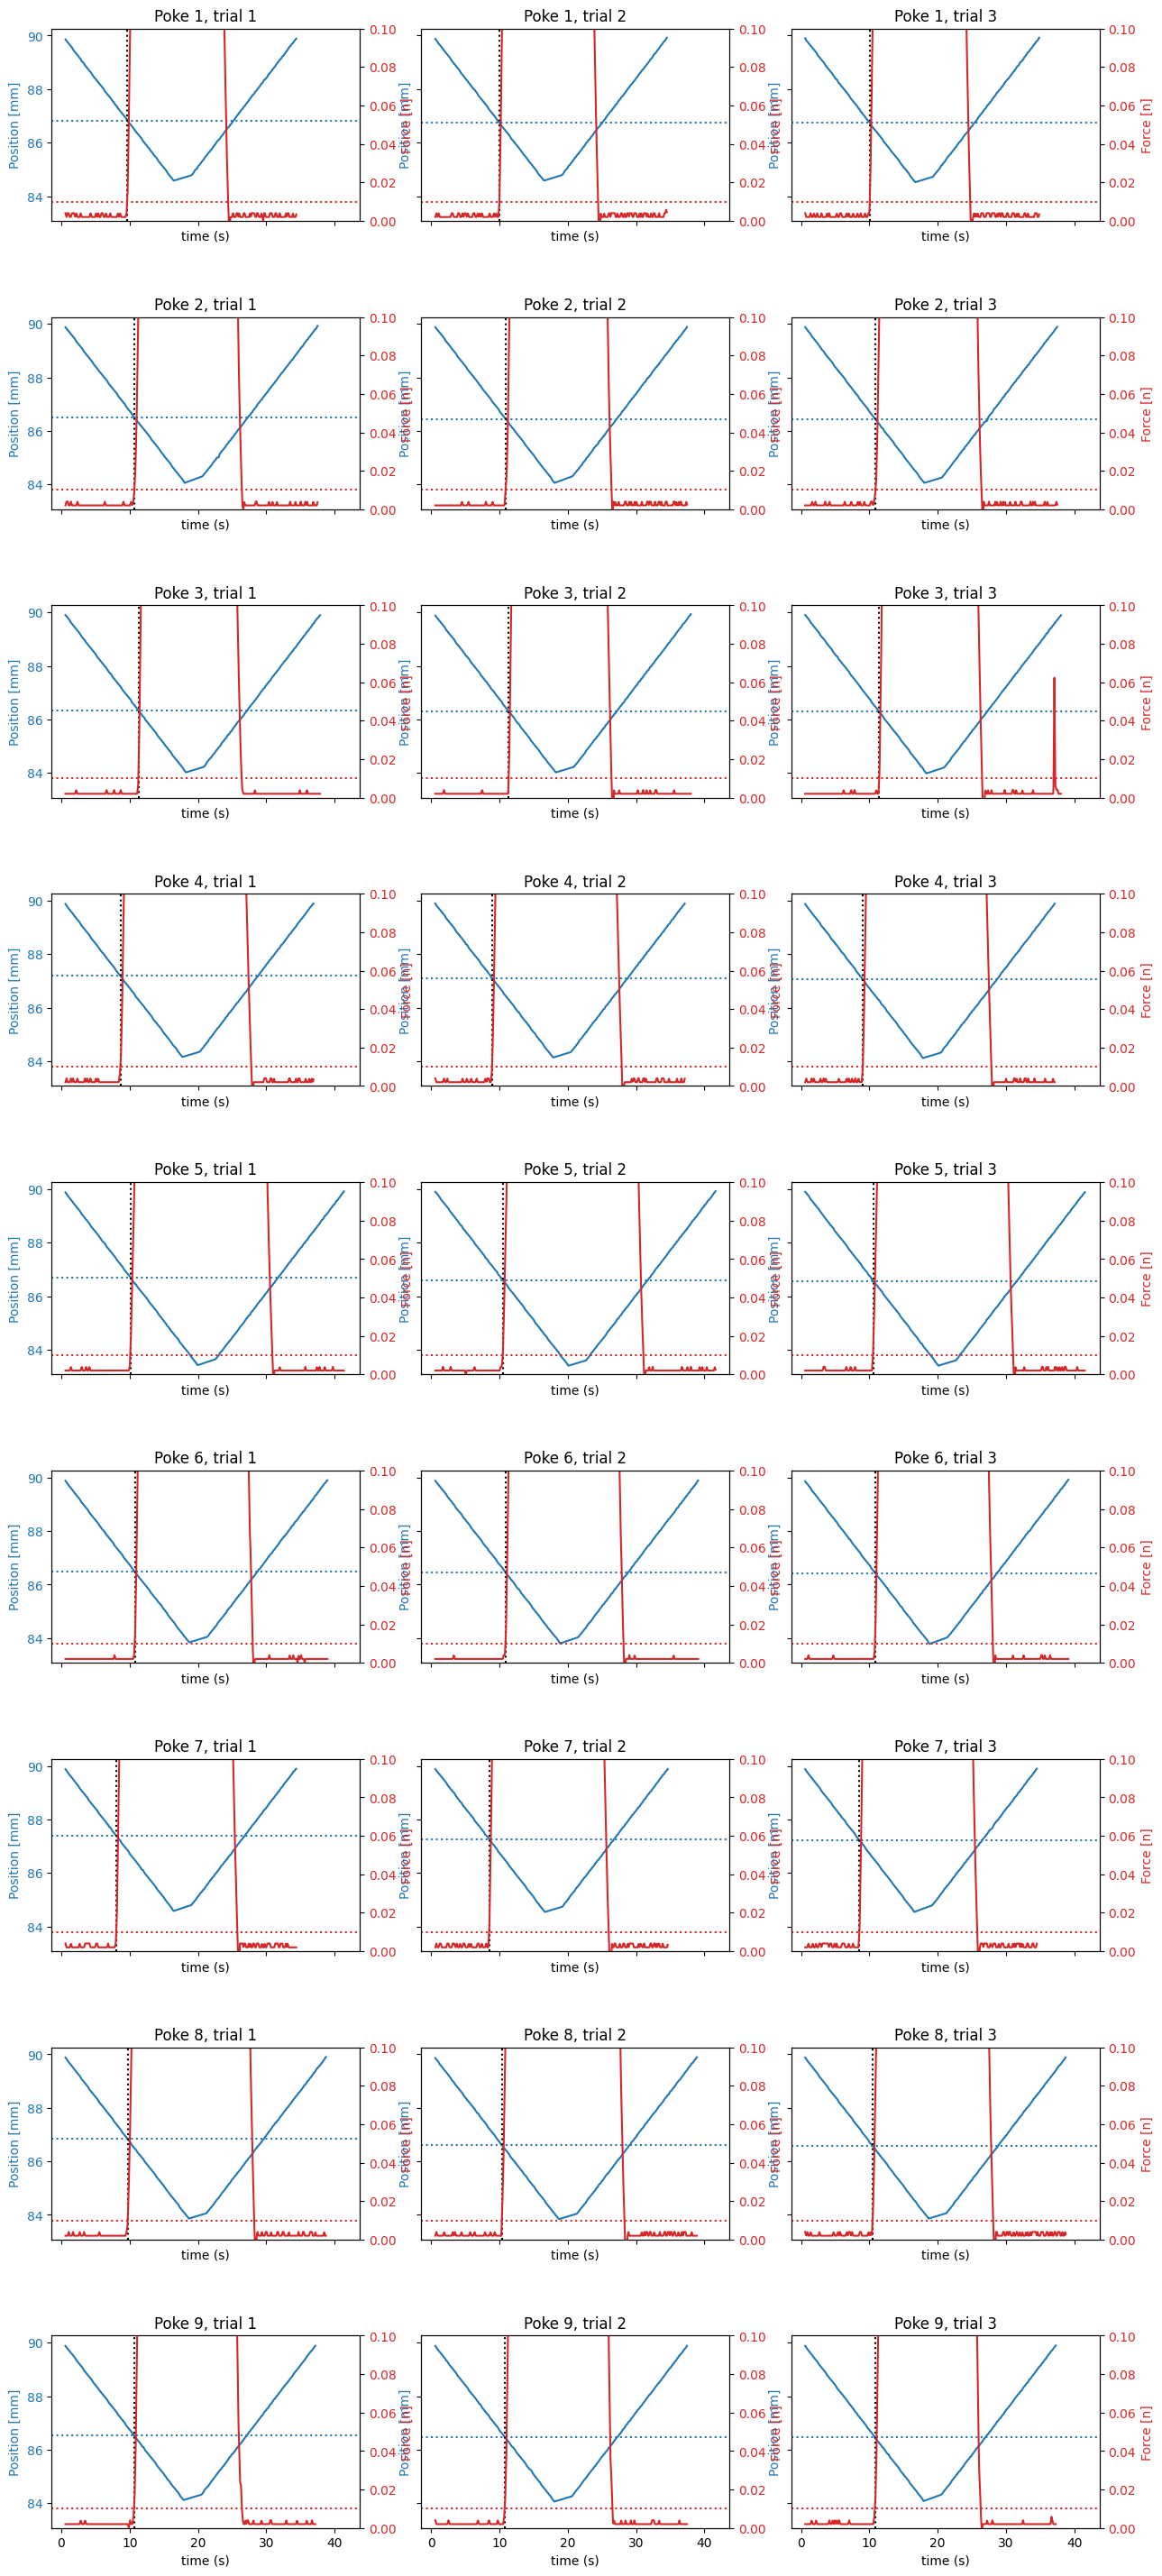

In [ ]:
# Plot position vs time and force vs time for all three trials of poke 1
def plot_pos_and_force_over_time(df_data, ax1):
  
    color = 'tab:blue'
    ax1.set_xlabel('time (s)')
    ax1.set_ylabel('Position [mm]', color=color)
    ax1.plot(df_data["time_s"], df_data["position_mm"], color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    
    ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
    
    color = 'tab:red'
    ax2.set_ylabel('Force [n]', color=color)  # we already handled the x-label with ax1
    ax2.plot(df_data["time_s"], df_data["force_N"], color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    ax2.set_ylim([0, 10])
    return ax1, ax2

def get_compression_posns(df_data, force_threshold):
    mask_compressing = df_data_i["force_N"] > force_threshold
    i_compression_start = np.nonzero(mask_compressing)[0][0]
    x_compression_start = df_data_i["position_mm"][i_compression_start]

    # Now compare against the bottomed out position to find the dx
    x_bottom = np.min(df_data_i["position_mm"])
    
    return i_compression_start, x_compression_start, x_bottom

N_pokes = 9
N_repeats = 3

mat_dxs = np.zeros([N_pokes, N_repeats])

fig, axs = plt.subplots(nrows=N_pokes, ncols=N_repeats, figsize=(15, 4*N_pokes), sharey=True, sharex=True)
for i_poke in range(N_pokes):
    for i_repeat in range(N_repeats):
        df_data_i = list_poke_dfs[i_poke][i_repeat]
        ax1, ax2 = plot_pos_and_force_over_time(df_data_i, axs[i_poke][i_repeat])
        plt.title(f"Poke {i_poke+1}, trial {i_repeat+1}")

        force_threshold = 0.01
        ax2.set_ylim([0, 0.1])
        i_compression_start, x_compression_start, x_bottom = get_compression_posns(df_data_i, force_threshold)
        dx_compression = x_bottom - x_compression_start

        print(f"Poke {i_poke+1} test {i_repeat+1}, Compression start at {x_compression_start:.3f}, Compression end at {x_bottom:.3f}, dx is {dx_compression:.3f}")
        ax1.axhline(y=x_compression_start, color="tab:blue", linestyle=":")
        ax2.axhline(y=force_threshold, color="tab:red", linestyle=":")
        ax1.axvline(x=df_data_i["time_s"][i_compression_start], color="k", linestyle=":")

        mat_dxs[i_poke, i_repeat] = dx_compression
        
fig.subplots_adjust(hspace=0.5)

Poke 1 mean dx: -2.2052691435612055
Poke 2 mean dx: -2.401563346910905
Poke 3 mean dx: -2.295718777585383
Poke 4 mean dx: -2.976217027496247
Poke 5 mean dx: -3.214470248201588
Poke 6 mean dx: -2.6428738326413046
Poke 7 mean dx: -2.731147969675831
Poke 8 mean dx: -2.8088213908015027
Poke 9 mean dx: -2.399373542535926


([<matplotlib.axis.YTick at 0x7478c269e210>,
 [Text(0, 0, '0'), Text(0, 1, '1'), Text(0, 2, '2')])

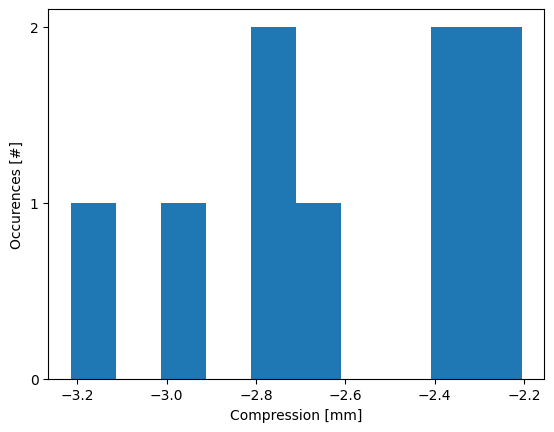

In [114]:
mean_dxs = np.mean(mat_dxs, 1)

for i, mean_dx_i in enumerate(mean_dxs):
    print(f"Poke {i+1} mean dx: {mean_dx_i}")

fig = plt.figure()
plt.hist(mean_dxs)
plt.xlabel("Compression [mm]")
plt.ylabel("Occurences [#]")
plt.yticks([0, 1, 2])

In [ ]:
# TODO - Force vs Pressure in 